In [3]:
#debug dependency issue
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.4 MB/s eta 0:00:00


In [4]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
# current version of seaborn generates a bunch of warnings that we'll ignore
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


import gc
import datetime

#import missingno as msno # missing data visualization module for Python
from ydata_profiling import ProfileReport

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Uploading Data Files

upload`global_movies.csv` and `classic_movies.csv` files toGoogle Drive.


In [6]:
# Define the path to files in Google Drive
file_path_global = '/content/drive/MyDrive/Colab Notebooks/data/global_movies.csv'
file_path_classic = '/content/drive/MyDrive/Colab Notebooks/data/classic_movies.csv'

# Check if the files exist in the specified Drive path
import os
print(f"Checking for global_movies.csv in Drive: {os.path.exists(file_path_global)}")
print(f"Checking for classic_movies.csv in Drive: {os.path.exists(file_path_classic)}")

Checking for global_movies.csv in Drive: True
Checking for classic_movies.csv in Drive: True


In [7]:
# Load the datasets from Google Drive
movies = pd.read_csv(file_path_global)
classics = pd.read_csv(file_path_classic)

# Display the first few rows to confirm successful loading
print("Global Movies Data:")
display(movies.head())
print("\nClassic Movies Data:")
display(classics.head())

Global Movies Data:


,movie_id,title,release_year,decade,runtime_min,genre,subgenre,director,lead_actor,lead_actress,...,roi_pct,popularity_score,metascore,audience_score,streaming_platform,award_nominations,award_wins,top_100_prob,blockbuster_flag,franchise_flag
0,1,Crimson Code,2001,2000,116,Action|Drama|Sci-Fi,Superhero,Denis Villeneuve,Brad Pitt,Tom Hanks,...,98.0,82.54,60,74,Netflix,3,2,0.560,0,0
1,2,Lost Empire,1951,1950,85,Crime|Animation,Gangster,Christopher Nolan,Scarlett Johansson,Brad Pitt,...,139.3,80.54,64,56,MGM+,0,0,0.549,0,0
2,3,Last Legacy,1990,1990,141,Sci-Fi|Drama,Cyberpunk,Bong Joon-ho,Emma Stone,Brad Pitt,...,-45.5,81.98,59,60,Peacock,1,1,0.520,0,0
3,4,Crimson River,1952,1950,82,Mystery|Romance,Whodunit,Quentin Tarantino,Meryl Streep,Tom Hanks,...,57.4,72.10,69,77,Disney+,1,1,0.498,0,0
4,5,Lost Dream,2011,2010,130,Romance,Romantic Drama,Quentin Tarantino,Robert Downey Jr.,Timothee Chalamet,...,97.8,60.63,48,57,Prime Video,0,0,0.435,0,0



Classic Movies Data:


,Title,ReleaseDate,Overview,VoteAverage,VoteCount,OriginalLanguage,Genres,Runtime,Tagline,Budget,Revenue,ProductionCompanies,ProductionCountries,SpokenLanguages,IMDBId
0,Eyes Without a Face,1960-01-11,Dr. Génessier is riddled with guilt after an a...,7.589,689,fr,Drama;Horror;Thriller,84,Beautiful women were the victims of his fiendi...,0,58656,Lux Film;Champs-Élysées Productions,France;Italy,Français,tt0053459
1,Cash McCall,1960-01-20,Wealthy hotshot Cash McCall makes his money by...,6.000,13,en,Comedy;Drama;Romance,102,High finance and high romance are about to merge.,0,0,Warner Bros. Pictures,United States of America,English,tt0052680
2,Toby Tyler or Ten Weeks with a Circus,1960-01-21,"Angered at stern Uncle Daniel, Toby Tyler runs...",6.100,24,en,Drama;Family,95,Here comes...the HAPPIEST SHOW ON EARTH!,0,0,Walt Disney Productions,United States of America,English,tt0054390
3,Hell Bent for Leather,1960-02-01,When Clay Santell stops in the town of Sutterv...,6.155,29,en,Western,82,Target For Terror!,0,0,Universal International Pictures,United States of America,English,tt0053899
4,The Rise and Fall of Legs Diamond,1960-02-03,Jack Diamond and his sickly brother arrive in ...,5.800,19,en,Crime;History,101,The Wildest Mobster of the Roaring Twenties!,0,0,United States Pictures,United States of America,Français;English;Italiano;Deutsch,tt0054243


In [8]:
# Check classics csv
classics.head(25)

,Title,ReleaseDate,Overview,VoteAverage,VoteCount,OriginalLanguage,Genres,Runtime,Tagline,Budget,Revenue,ProductionCompanies,ProductionCountries,SpokenLanguages,IMDBId
0,Eyes Without a Face,1960-01-11,Dr. Génessier is riddled with guilt after an a...,7.589,689,fr,Drama;Horror;Thriller,84,Beautiful women were the victims of his fiendi...,0,58656,Lux Film;Champs-Élysées Productions,France;Italy,Français,tt0053459
1,Cash McCall,1960-01-20,Wealthy hotshot Cash McCall makes his money by...,6.000,13,en,Comedy;Drama;Romance,102,High finance and high romance are about to merge.,0,0,Warner Bros. Pictures,United States of America,English,tt0052680
2,Toby Tyler or Ten Weeks with a Circus,1960-01-21,"Angered at stern Uncle Daniel, Toby Tyler runs...",6.100,24,en,Drama;Family,95,Here comes...the HAPPIEST SHOW ON EARTH!,0,0,Walt Disney Productions,United States of America,English,tt0054390
3,Hell Bent for Leather,1960-02-01,When Clay Santell stops in the town of Sutterv...,6.155,29,en,Western,82,Target For Terror!,0,0,Universal International Pictures,United States of America,English,tt0053899
4,The Rise and Fall of Legs Diamond,1960-02-03,Jack Diamond and his sickly brother arrive in ...,5.800,19,en,Crime;History,101,The Wildest Mobster of the Roaring Twenties!,0,0,United States Pictures,United States of America,Français;English;Italiano;Deutsch,tt0054243
5,Visit to a Small Planet,1960-02-04,The weirdest alien of the galaxy pays a visit ...,5.300,29,en,Comedy;Science Fiction;Family,85,The space race is on and Jerry's leading it......,0,0,Paramount Pictures;Hal Wallis Productions,United States of America,English,tt0054446
6,La Dolce Vita,1960-02-05,Episodic journey of journalist Marcello who st...,8.096,1795,it,Comedy;Drama,176,The world’s most talked about movie today!,0,19647000,Cinecittà Studios;Pathé Consortium Cinéma;Riam...,France;Italy,Deutsch;English;Français;Italiano,tt0053779
7,The Virgin Spring,1960-02-08,Devout Christians Töre and Märeta send their o...,7.827,594,sv,Drama;History,90,Ravished innocence... brings terrible revenge!,0,700000,SF Studios,Sweden,Deutsch;svenska,tt0053976
8,"Once More, with Feeling!",1960-02-11,"The wife of brilliant, but boisterous and ill-...",5.800,5,en,Comedy;Drama;Romance,92,NaN,0,0,Stanley Donen Films;Columbia Pictures,United States of America,English;Français,tt0054141
9,The Hypnotic Eye,1960-02-17,A mysterious hypnotist is suspected by the pol...,5.955,22,en,Horror,79,Beware his hypnotic power that turns human fle...,365000,0,Bloch/Woodfield Productions;Penguin Production...,United States of America,English,tt0053931


In [9]:
movies.info()
#check movies columns and datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   movie_id                  100000 non-null  int64  
 1   title                     100000 non-null  object 
 2   release_year              100000 non-null  int64  
 3   decade                    100000 non-null  int64  
 4   runtime_min               100000 non-null  int64  
 5   genre                     100000 non-null  object 
 6   subgenre                  100000 non-null  object 
 7   director                  100000 non-null  object 
 8   lead_actor                100000 non-null  object 
 9   lead_actress              100000 non-null  object 
 10  country                   100000 non-null  object 
 11  language                  100000 non-null  object 
 12  imdb_rating               100000 non-null  float64
 13  votes                     100000 non-null  in

In [10]:
classics.info()
#check classics columns and datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4023 entries, 0 to 4022
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                4023 non-null   object 
 1   ReleaseDate          4023 non-null   object 
 2   Overview             4023 non-null   object 
 3   VoteAverage          4023 non-null   float64
 4   VoteCount            4023 non-null   int64  
 5   OriginalLanguage     4023 non-null   object 
 6   Genres               4016 non-null   object 
 7   Runtime              4023 non-null   int64  
 8   Tagline              3754 non-null   object 
 9   Budget               4023 non-null   int64  
 10  Revenue              4023 non-null   int64  
 11  ProductionCompanies  3974 non-null   object 
 12  ProductionCountries  3991 non-null   object 
 13  SpokenLanguages      4012 non-null   object 
 14  IMDBId               4017 non-null   object 
dtypes: float64(1), int64(4), object(10)
me

In [11]:
classics['classic_flag'] = 1
classics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4023 entries, 0 to 4022
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                4023 non-null   object 
 1   ReleaseDate          4023 non-null   object 
 2   Overview             4023 non-null   object 
 3   VoteAverage          4023 non-null   float64
 4   VoteCount            4023 non-null   int64  
 5   OriginalLanguage     4023 non-null   object 
 6   Genres               4016 non-null   object 
 7   Runtime              4023 non-null   int64  
 8   Tagline              3754 non-null   object 
 9   Budget               4023 non-null   int64  
 10  Revenue              4023 non-null   int64  
 11  ProductionCompanies  3974 non-null   object 
 12  ProductionCountries  3991 non-null   object 
 13  SpokenLanguages      4012 non-null   object 
 14  IMDBId               4017 non-null   object 
 15  classic_flag         4023 non-null   i

In [12]:
#standardise columns

movies.columns = (
    movies.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

classics.columns = (
    classics.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [13]:
# change to cleaner snake_case names

classics = classics.rename(columns={
    "releasedate": "release_date",
    "voteaverage": "vote_average",
    "votecount": "vote_count",
    "originallanguage": "original_language",
    "productioncompanies": "production_companies",
    "productioncountries": "production_countries",
    "spokenlanguages": "spoken_languages",
    "imdbid": "imdb_id"
})

In [14]:
#keep copy of raw datasets in case anything happens

movies_raw = movies.copy()
classics_raw = classics.copy()

In [15]:
print("Movies shape:", movies.shape)
print("Classics shape:", classics.shape)

print("\nMovies data types:")
print(movies.dtypes)

print("\nClassics data types:")
print(classics.dtypes)

Movies shape: (100000, 27)
Classics shape: (4023, 16)

Movies data types:
movie_id                      int64
title                        object
release_year                  int64
decade                        int64
runtime_min                   int64
genre                        object
subgenre                     object
director                     object
lead_actor                   object
lead_actress                 object
country                      object
language                     object
imdb_rating                 float64
votes                         int64
budget_million              float64
marketing_budget_million    float64
revenue_million             float64
roi_pct                     float64
popularity_score            float64
metascore                     int64
audience_score                int64
streaming_platform           object
award_nominations             int64
award_wins                    int64
top_100_prob                float64
blockbuster_flag          

In [16]:
# Check for duplicates

print("Movies duplicates:", movies.duplicated().sum())
print("Classics duplicates:", classics.duplicated().sum())

# duplicates for classics only

Movies duplicates: 0
Classics duplicates: 9


In [17]:
# View duplicates
duplicate_rows = classics[
    classics.duplicated(keep=False)
]

display(duplicate_rows)


,title,release_date,overview,vote_average,vote_count,original_language,genres,runtime,tagline,budget,revenue,production_companies,production_countries,spoken_languages,imdb_id,classic_flag
2044,Home Alone 2: Lost in New York,1992-11-15,"Instead of flying to Florida with his folks, K...",6.743,9369,en,Comedy;Family;Adventure,120,He's up past his bedtime in the city that neve...,18000000,358994850,20th Century Fox;Hughes Entertainment,United States of America,English;Français,tt0104431,1
2045,Home Alone 2: Lost in New York,1992-11-15,"Instead of flying to Florida with his folks, K...",6.743,9369,en,Comedy;Family;Adventure,120,He's up past his bedtime in the city that neve...,18000000,358994850,20th Century Fox;Hughes Entertainment,United States of America,English;Français,tt0104431,1
2625,Monster,2003-12-24,An emotionally scarred highway drifter shoots ...,7.223,2251,en,Crime;Drama,110,Based on a true story,8000000,60400000,Newmarket Films;Media 8 Entertainment;DEJ Prod...,United States of America,English,tt0340855,1
2627,Monster,2003-12-24,An emotionally scarred highway drifter shoots ...,7.223,2251,en,Crime;Drama,110,Based on a true story,8000000,60400000,Newmarket Films;Media 8 Entertainment;DEJ Prod...,United States of America,English,tt0340855,1
2642,The Girl Next Door,2004-04-09,Exceptionally ambitious high schooler Matthew ...,6.721,3409,en,Comedy;Romance,110,Matt never saw her coming... but all his frien...,21000000,31635150,Epsilon Motion Pictures;Regency Enterprises;Ne...,Switzerland;United States of America,English,tt0265208,1
2645,The Girl Next Door,2004-04-09,Exceptionally ambitious high schooler Matthew ...,6.721,3409,en,Comedy;Romance,110,Matt never saw her coming... but all his frien...,21000000,31635150,Epsilon Motion Pictures;Regency Enterprises;Ne...,Switzerland;United States of America,English,tt0265208,1
2683,Howl's Moving Castle,2004-09-09,"Sophie, a young milliner, is turned into an el...",8.406,9640,ja,Fantasy;Animation;Adventure,119,The two lived there.,24000000,236049757,Studio Ghibli;dentsu Music And Entertainment;M...,Japan,日本語,tt0347149,1
2684,Howl's Moving Castle,2004-09-09,"Sophie, a young milliner, is turned into an el...",8.406,9640,ja,Fantasy;Animation;Adventure,119,The two lived there.,24000000,236049757,Studio Ghibli;dentsu Music And Entertainment;M...,Japan,日本語,tt0347149,1
2689,Friday Night Lights,2004-10-08,"A small, turbulent town in Texas obsesses over...",6.883,541,en,Drama,118,Hope comes alive on Friday nights.,30000000,61255921,Imagine Entertainment;Friday Night Lights;MDBF...,United States of America,English,tt0390022,1
2691,Friday Night Lights,2004-10-08,"A small, turbulent town in Texas obsesses over...",6.883,541,en,Drama,118,Hope comes alive on Friday nights.,30000000,61255921,Imagine Entertainment;Friday Night Lights;MDBF...,United States of America,English,tt0390022,1


In [18]:
# true duplicates, so drop duplicates
classics = classics.drop_duplicates().copy()

#check again
print("Remaining duplicates:", classics.duplicated().sum())
print("New classics shape:", classics.shape)

#done because duplicate movies could artificially increase the number of positive classic_flag=1 observations and bias the model

Remaining duplicates: 0
New classics shape: (4014, 16)


In [19]:
# check for null values

print("MOVIES")
print(movies.isnull().sum().sort_values(ascending=False))

print("\nCLASSICS")
print(classics.isnull().sum().sort_values(ascending=False))

#no null values for movies.
#some null values for classics.

MOVIES
movie_id                    0
title                       0
release_year                0
decade                      0
runtime_min                 0
genre                       0
subgenre                    0
director                    0
lead_actor                  0
lead_actress                0
country                     0
language                    0
imdb_rating                 0
votes                       0
budget_million              0
marketing_budget_million    0
revenue_million             0
roi_pct                     0
popularity_score            0
metascore                   0
audience_score              0
streaming_platform          0
award_nominations           0
award_wins                  0
top_100_prob                0
blockbuster_flag            0
franchise_flag              0
dtype: int64

CLASSICS
tagline                 268
production_companies     49
production_countries     32
spoken_languages         11
genres                    7
imdb_id             

In [20]:
# some of these null fields are not useful for modeling since it only exists in the classics dataset and not the movies dataset.
# but in case we need it as secondary information for joining, leave them be and fill the null values as 'Unknown'

classics["tagline"] = classics["tagline"].fillna("Unknown")
classics["production_companies"] = classics["production_companies"].fillna("Unknown")
classics["production_countries"] = classics["production_countries"].fillna("Unknown")
classics["spoken_languages"] = classics["spoken_languages"].fillna("Unknown")
classics["genres"] = classics["genres"].fillna("Unknown") #we can use the genres from the movies dataset
classics["imdb_id"] = classics["imdb_id"].fillna("Unknown")

print("\nCLASSICS")
print(classics.isnull().sum().sort_values(ascending=False))


CLASSICS
title                   0
release_date            0
overview                0
vote_average            0
vote_count              0
original_language       0
genres                  0
runtime                 0
tagline                 0
budget                  0
revenue                 0
production_companies    0
production_countries    0
spoken_languages        0
imdb_id                 0
classic_flag            0
dtype: int64


In [21]:
# Standardise movie titles

import re
import unicodedata


In [22]:
def clean_title(title):
    if pd.isna(title):
        return ""

    title = str(title)

    # Convert accented characters
    title = unicodedata.normalize("NFKD", title)
    title = "".join(
        char for char in title
        if not unicodedata.combining(char)
    )

    # Lowercase
    title = title.lower()

    # Replace & with 'and'
    title = title.replace("&", "and")

    # Remove punctuation
    title = re.sub(r"[^a-z0-9\s]", " ", title)

    # Remove extra spaces
    title = re.sub(r"\s+", " ", title).strip()

    return title

In [23]:
#apply
movies["title_clean"] = movies["title"].apply(clean_title)
classics["title_clean"] = classics["title"].apply(clean_title)

In [24]:
#check
print(movies[["title", "title_clean"]].head(10))
print(classics[["title", "title_clean"]].head(10))

# these steps increase matching reliability

              title       title_clean
0      Crimson Code      crimson code
1       Lost Empire       lost empire
2       Last Legacy       last legacy
3     Crimson River     crimson river
4        Lost Dream        lost dream
5    Broken Promise    broken promise
6     Silent Garden     silent garden
7  Invisible Garden  invisible garden
8    Falling Garden    falling garden
9      Dark Promise      dark promise
                                   title  \
0                    Eyes Without a Face   
1                            Cash McCall   
2  Toby Tyler or Ten Weeks with a Circus   
3                  Hell Bent for Leather   
4      The Rise and Fall of Legs Diamond   
5                Visit to a Small Planet   
6                          La Dolce Vita   
7                      The Virgin Spring   
8               Once More, with Feeling!   
9                       The Hypnotic Eye   

                             title_clean  
0                    eyes without a face  
1          

In [25]:
# convert release date to year on classics
classics["release_date"] = pd.to_datetime(
    classics["release_date"],
    errors="coerce"
)

classics["release_year"] = classics["release_date"].dt.year

#check
classics[
    ["title", "release_date", "release_year"]
].head()

,title,release_date,release_year
0,Eyes Without a Face,1960-01-11,1960
1,Cash McCall,1960-01-20,1960
2,Toby Tyler or Ten Weeks with a Circus,1960-01-21,1960
3,Hell Bent for Leather,1960-02-01,1960
4,The Rise and Fall of Legs Diamond,1960-02-03,1960


In [26]:
#validate release years
print(
    movies["release_year"].min(),
    movies["release_year"].max()
)

print(
    classics["release_year"].min(),
    classics["release_year"].max()
)

1950 2026
1960 2019


In [27]:
# check if there are any unusual years
movies["release_year"].value_counts().sort_index()

,count
release_year,
1950,1293
1951,1265
1952,1217
1953,1276
1954,1286
...,...
2022,1309
2023,1350
2024,1249


In [28]:
# standardise text categorical variables
text_cols = [
    "genre",
    "subgenre",
    "director",
    "lead_actor",
    "lead_actress",
    "country",
    "language",
    "streaming_platform"
]

for col in text_cols:
    movies[col] = (
        movies[col]
        .astype(str)
        .str.strip()
    )

In [29]:
#lowercase genre
movies["genre_clean"] = (
    movies["genre"]
    .str.lower()
    .str.strip()
)

classics["genres_clean"] = (
    classics["genres"]
    .fillna("")
    .str.lower()
    .str.strip()
)

In [30]:
print(movies["genre"].value_counts())

print(classics["genres"].value_counts())

genre
Horror                        2218
Adventure                     2197
Comedy                        2189
Thriller                      2177
Drama                         2177
                              ... 
Animation|Comedy|Adventure       2
Mystery|Horror|Drama             2
Comedy|Horror|Action             1
Fantasy|Thriller|Drama           1
Romance|Thriller|Mystery         1
Name: count, Length: 1885, dtype: int64
genres
Drama                            249
Comedy                           248
Drama;Romance                    143
Comedy;Romance                   122
Western                           80
                                ... 
Drama;Comedy;Thriller;History      1
Drama;Mystery;Crime                1
Western;Comedy;Drama               1
Horror;War;Science Fiction         1
Crime;Drama;History;Thriller       1
Name: count, Length: 1086, dtype: int64


In [31]:
# check inconsistent categories
print(movies["language"].value_counts())
print(movies["country"].value_counts())
print(movies["blockbuster_flag"].value_counts())
print(movies["franchise_flag"].value_counts())

language
German      11262
French      11224
Korean      11217
Hindi       11149
English     11113
Spanish     11075
Mandarin    11022
Italian     10999
Japanese    10939
Name: count, dtype: int64
country
India          10165
UK             10095
Italy          10059
Germany        10022
South Korea    10019
Canada         10004
Japan          10000
France          9886
USA             9877
Australia       9873
Name: count, dtype: int64
blockbuster_flag
0    77472
1    22528
Name: count, dtype: int64
franchise_flag
0    81958
1    18042
Name: count, dtype: int64


In [32]:
#check flags
print(movies["blockbuster_flag"].unique())
print(movies["franchise_flag"].unique())

[0 1]
[0 1]


In [33]:
#check numeric ranges

numeric_cols = [
    "runtime_min",
    "imdb_rating",
    "votes",
    "budget_million",
    "marketing_budget_million",
    "revenue_million",
    "roi_pct",
    "popularity_score",
    "metascore",
    "audience_score",
    "award_nominations",
    "award_wins"
]

movies[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
runtime_min,100000.0,113.712660,20.218836,70.00,100.00,114.000,127.0000,205.00
imdb_rating,100000.0,6.736212,1.014200,2.20,6.10,6.700,7.4000,9.80
votes,100000.0,40204.260940,52127.491206,425.00,12440.00,24305.000,47767.2500,1539859.00
budget_million,100000.0,48.269718,43.584906,0.50,16.07,34.860,68.0000,284.42
marketing_budget_million,100000.0,22.966829,24.086906,0.10,6.32,14.960,31.0100,180.00
revenue_million,100000.0,133.313829,196.396971,0.06,24.42,66.145,159.5625,2940.58
roi_pct,100000.0,176.872003,238.856193,-90.00,14.80,100.900,253.9250,1100.60
popularity_score,100000.0,80.080743,10.169402,33.84,73.18,80.160,87.2600,100.00
metascore,100000.0,66.721890,15.458479,10.00,56.00,67.000,77.0000,100.00
audience_score,100000.0,69.739070,14.034926,12.00,60.00,70.000,79.0000,100.00


In [34]:
# check for invalid numeric ranges
print(
    "Invalid IMDb:",
    ((movies["imdb_rating"] < 0) |
     (movies["imdb_rating"] > 10)).sum()
)

print(
    "Invalid Metascore:",
    ((movies["metascore"] < 0) |
     (movies["metascore"] > 100)).sum()
)

print(
    "Invalid Audience Score:",
    ((movies["audience_score"] < 0) |
     (movies["audience_score"] > 100)).sum()
)

print(
    "Invalid Runtime:",
    (movies["runtime_min"] <= 0).sum()
)

Invalid IMDb: 0
Invalid Metascore: 0
Invalid Audience Score: 0
Invalid Runtime: 0


In [35]:
#check if extreme numbers makes sense

movies[
    ["budget_million",
     "revenue_million",
     "roi_pct",
     "votes"]
].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
)

,budget_million,revenue_million,roi_pct,votes
count,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,48.269718,133.313829,176.872003,4.020426e+04
std,43.584906,196.396971,238.856193,5.212749e+04
min,0.500000,0.060000,-90.000000,4.250000e+02
1%,0.500000,0.470000,-71.500000,2.409000e+03
5%,0.500000,1.970000,-49.600000,4.686000e+03
25%,16.070000,24.420000,14.800000,1.244000e+04
50%,34.860000,66.145000,100.900000,2.430500e+04
75%,68.000000,159.562500,253.925000,4.776725e+04
95%,139.860500,492.170500,686.800000,1.276732e+05


In [36]:
Q1 = movies["revenue_million"].quantile(0.25)
Q3 = movies["revenue_million"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

revenue_anomalies = movies[
    (movies["revenue_million"] < lower_bound) |
    (movies["revenue_million"] > upper_bound)
]

display(
    revenue_anomalies[
        ["title", "release_year", "revenue_million"]
    ].sort_values("revenue_million", ascending=False)
)

,title,release_year,revenue_million
31117,Invisible Empire,2000,2940.58
46719,Wild Empire,1989,2764.91
96788,Midnight Secret,2011,2561.73
80284,Lost Game,1954,2520.43
54652,Lost Signal,1985,2457.90
...,...,...,...
21510,Broken Storm,1996,362.57
70988,Crimson River,2016,362.52
56299,Invisible Shadow,2010,362.52
54763,Last Promise,1987,362.31


In [37]:
#check duplicate title+year combinations - important for merge
duplicate_title_year = movies[
    movies.duplicated(
        subset=["title_clean", "release_year"],
        keep=False
    )
]

print(
    "Duplicate title-year records:",
    len(duplicate_title_year)
)

Duplicate title-year records: 99702


In [38]:
# First, make sure title_clean exists
movies["title_clean"] = movies["title"].apply(clean_title)

# Then recreate the duplicate dataframe
duplicate_title_year = movies[
    movies.duplicated(
        subset=["title_clean", "release_year"],
        keep=False
    )
].copy()

# Display duplicate title/year records
display(
    duplicate_title_year[
        [
            "movie_id",
            "title",
            "title_clean",
            "release_year",
            "genre",
            "runtime_min"
        ]
    ]
    .sort_values(["title_clean", "release_year"])
    .head(30)
)

,movie_id,title,title_clean,release_year,genre,runtime_min
83774,83775,Broken City,broken city,1950,Comedy|Horror|Documentary,106
87308,87309,Broken City,broken city,1950,Mystery|Comedy,123
90846,90847,Broken City,broken city,1950,Horror|Crime,146
96908,96909,Broken City,broken city,1950,Drama|Action|Comedy,163
357,358,Broken City,broken city,1951,Horror,113
10070,10071,Broken City,broken city,1951,Action|Animation|Documentary,99
12785,12786,Broken City,broken city,1951,Mystery|Comedy,103
14364,14365,Broken City,broken city,1951,Comedy|Animation,122
21613,21614,Broken City,broken city,1951,Romance|Horror,157
22936,22937,Broken City,broken city,1951,Thriller,84


In [39]:
#create match key
movies["match_key"] = (
    movies["title_clean"]
    + "_"
    + movies["release_year"].astype(str)
)

classics["match_key"] = (
    classics["title_clean"]
    + "_"
    + classics["release_year"]
        .astype("Int64")
        .astype(str)
)

#inspect
movies[
    ["title", "release_year", "match_key"]
].head()

,title,release_year,match_key
0,Crimson Code,2001,crimson code_2001
1,Lost Empire,1951,lost empire_1951
2,Last Legacy,1990,last legacy_1990
3,Crimson River,1952,crimson river_1952
4,Lost Dream,2011,lost dream_2011


In [40]:
#check duplicates by matching key

movies[
    ["title", "release_year", "match_key"]
].head()

,title,release_year,match_key
0,Crimson Code,2001,crimson code_2001
1,Lost Empire,1951,lost empire_1951
2,Last Legacy,1990,last legacy_1990
3,Crimson River,1952,crimson river_1952
4,Lost Dream,2011,lost dream_2011


In [41]:
display(
    classics[
        classics.duplicated(
            subset=["match_key"],
            keep=False
        )
    ].sort_values("match_key")
)

,title,release_date,overview,vote_average,vote_count,original_language,genres,runtime,tagline,budget,revenue,production_companies,production_countries,spoken_languages,imdb_id,classic_flag,title_clean,release_year,genres_clean,match_key


In [42]:
classics["match_key"].value_counts().head(10)

,count
match_key,
little women_2019,1
eyes without a face_1960,1
cash mccall_1960,1
toby tyler or ten weeks with a circus_1960,1
hell bent for leather_1960,1
the rise and fall of legs diamond_1960,1
visit to a small planet_1960,1
la dolce vita_1960,1
the virgin spring_1960,1


In [43]:
#create comparable version of budget and revenue

classics["budget_million"] = (
    classics["budget"] / 1_000_000
)

classics["revenue_million"] = (
    classics["revenue"] / 1_000_000
)

In [44]:
# standardise runtime

#rename column
classics = classics.rename(
    columns={"runtime": "runtime_min"}
)

# ensure numeric
classics["runtime_min"] = pd.to_numeric(
    classics["runtime_min"],
    errors="coerce"
)

In [45]:
#standardise IMDB

classics["imdb_id"] = (
    classics["imdb_id"]
    .astype("string")
    .str.strip()
    .str.lower()
)

In [46]:
# create smaller matching table of classics to prevent variables from the classics dataset accidentally becoming predictors later and causing leakage.

classic_match = classics[
    [
        "title",
        "title_clean",
        "release_year",
        "runtime_min",
        "genres",
        "imdb_id"
    ]
].copy()

In [47]:
#merge dataset

merged = movies.merge(
    classic_match,
    on=["title_clean", "release_year"],
    how="left",
    indicator=True,
    suffixes=("_movies", "_classics")
)

In [48]:
# check merge counts
merged["_merge"].value_counts()

#less matches than 893 matches using title alone. adding years does not agree with classics dataset

,count
_merge,
left_only,99991
both,9
right_only,0


In [49]:
merged["classic_flag"] = (
    merged["_merge"] == "both"
).astype(int)

In [50]:
# Cleaning summary
print("=== CLEANING SUMMARY ===")

print("Movies records:", len(movies))
print("Classics records:", len(classics))

print(
    "Movies missing values:",
    movies.isnull().sum().sum()
)

print(
    "Classics missing values:",
    classics.isnull().sum().sum()
)

print(
    "Movies exact duplicates:",
    movies.duplicated().sum()
)

print(
    "Classics exact duplicates:",
    classics.duplicated().sum()
)

=== CLEANING SUMMARY ===
Movies records: 100000
Classics records: 4014
Movies missing values: 0
Classics missing values: 0
Movies exact duplicates: 0
Classics exact duplicates: 0


In [51]:
#just do original merge at title and proceed with 893 matches.

title_merge = movies.merge(
    classic_match,
    on="title_clean",
    how="left",
    indicator=True,
    suffixes=("_movies", "_classics")
)

print(title_merge["_merge"].value_counts())

_merge
left_only     99107
both            893
right_only        0
Name: count, dtype: int64


In [52]:
# Get the cleaned titles found in the classics dataset
classic_titles = set(classics["title_clean"])

# Create target variable
movies["classic_flag"] = (
    movies["title_clean"]
    .isin(classic_titles)
    .astype(int)
)

print(movies["classic_flag"].value_counts())

print("\nPercentage:")
print(
    movies["classic_flag"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

#for the interest of time, all classic movie titles that don't match movies dataset are treated as non-classics.

classic_flag
0    99107
1      893
Name: count, dtype: int64

Percentage:
classic_flag
0    99.11
1     0.89
Name: proportion, dtype: float64


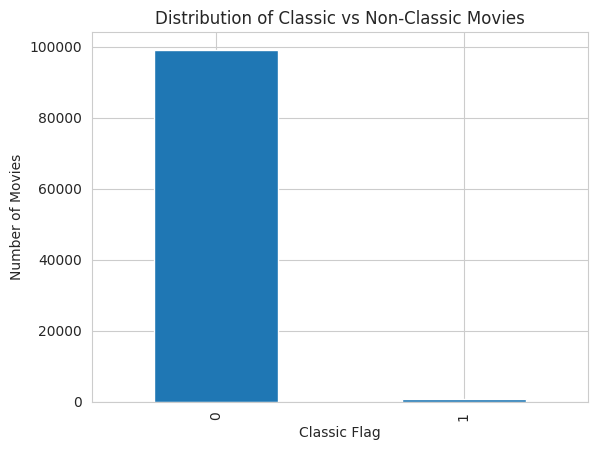

In [53]:
import matplotlib.pyplot as plt

class_counts = movies["classic_flag"].value_counts()

class_counts.plot(kind="bar")

plt.title("Distribution of Classic vs Non-Classic Movies")
plt.xlabel("Classic Flag")
plt.ylabel("Number of Movies")
plt.show()

#severely imbalanced classification problems.
#mterics to consider:
#Precision
#Recall
#F1-score
#ROC-AUC
#preferably PR-AUC

In [54]:
#Select Features
#numeric features
numeric_features = [
    "release_year",
    "runtime_min",
    "imdb_rating",
    "votes",
    "budget_million",
    "marketing_budget_million",
    "revenue_million",
    "roi_pct",
    "popularity_score",
    "metascore",
    "audience_score",
    "award_nominations",
    "award_wins",
    "franchise_flag"
]
#categorical features
categorical_features = [
    "genre",
    "subgenre",
    "country",
    "language",
]

#movie_id, title and title_clean are identifiers rather than useful generalisable characteristics.

# director, lead_actor and lead_actress may contain too many unique categories and unnecessarily complicate the first model.

#exclude top_100_prob because it appears to be a previously generated prediction variable.

#blockbuster_flag can be considered later but isn't necessary initially.

In [55]:
features = numeric_features + categorical_features

X = movies[features].copy()
y = movies["classic_flag"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 18)
y shape: (100000,)


In [56]:
# Train test split
# because data is heavily imbalanced, use stratification

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y #ensure both training and testing datasets contain approximately the same proportion of classics.
)

#check

print("Training:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training:
classic_flag
0    79286
1      714
Name: count, dtype: int64

Testing:
classic_flag
0    19821
1      179
Name: count, dtype: int64


In [57]:
#build preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [58]:
#for numeric variables
#inpute missing values using median
#standardise values
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

#for categorical variables
# impute missing values
#one-hot encoding so that it doesnt produce artifical numerical relationship

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [59]:
#combine
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [60]:
#Logistic Regression

class_weight="balanced"

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [61]:
#train logistic regression
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['release_year',
                                                   'runtime_min', 'imdb_rating',
                                                   'votes', 'budget_million',
                                                   'marketing_budget_million',
                                                   'revenue_million', 'roi_pct',
                                                   'popularity_score',
                                                   'metascore',
                                                   'audience_score',
                                                   'award_nominations',
                                                   'award_wins',
                                                   'franchise_flag']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['genre', 'subgenre',
                                                   'country', 'language'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [62]:
#predict
y_pred_log = logistic_model.predict(X_test)

y_prob_log = logistic_model.predict_proba(
    X_test
)[:, 1]

In [63]:
#evaluate logistic regression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print(
    classification_report(
        y_test,
        y_pred_log
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_log
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        y_prob_log
    )
)

              precision    recall  f1-score   support

           0       0.99      0.66      0.79     19821
           1       0.01      0.34      0.02       179

    accuracy                           0.65     20000
   macro avg       0.50      0.50      0.40     20000
weighted avg       0.98      0.65      0.78     20000

ROC-AUC: 0.5018705120324107
PR-AUC: 0.009678786495669382


In [64]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_log
)

print(cm)

[[13013  6808]
 [  118    61]]


In [65]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [66]:
#train decision tree
tree_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['release_year',
                                                   'runtime_min', 'imdb_rating',
                                                   'votes', 'budget_million',
                                                   'marketing_budget_million',
                                                   'revenue_million', 'roi_pct',
                                                   'popularity_score',
                                                   'metascore',
                                                   'audience_score',
                                                   'award_nominations',
                                                   'award_wins',
                                                   'franchise_flag']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['genre', 'subgenre',
                                                   'country', 'language'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=10,
                                        random_state=42))])

In [67]:
# predict decision treee
y_pred_tree = tree_model.predict(X_test)

y_prob_tree = tree_model.predict_proba(
    X_test
)[:, 1]

In [68]:
#evaluate decision tree
print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_tree
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        y_prob_tree
    )
)

              precision    recall  f1-score   support

           0       0.99      0.86      0.92     19821
           1       0.01      0.13      0.02       179

    accuracy                           0.85     20000
   macro avg       0.50      0.49      0.47     20000
weighted avg       0.98      0.85      0.91     20000

ROC-AUC: 0.4867828235895623
PR-AUC: 0.008756052445719358


In [69]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [70]:
#train random forest
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['release_year',
                                                   'runtime_min', 'imdb_rating',
                                                   'votes', 'budget_million',
                                                   'marketing_budget_million',
                                                   'revenue_million', 'roi_pct',
                                                   'popularity_score',
                                                   'metascore',
                                                   'audience_score',
                                                   'award_nominations',
                                                   'award_wins',
                                                   'franchise_flag']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['genre', 'subgenre',
                                                   'country', 'language'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_leaf=5, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [71]:
# predict random forest
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

In [72]:
#evaluate random forest
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_rf
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        y_prob_rf
    )
)

              precision    recall  f1-score   support

           0       0.99      0.96      0.98     19821
           1       0.01      0.03      0.01       179

    accuracy                           0.95     20000
   macro avg       0.50      0.49      0.49     20000
weighted avg       0.98      0.95      0.97     20000

ROC-AUC: 0.4892542444825321
PR-AUC: 0.009558791435630237


In [73]:
# create model comparison table
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf)
    ],

    "PR-AUC": [
        average_precision_score(
            y_test,
            y_prob_log
        ),
        average_precision_score(
            y_test,
            y_prob_tree
        ),
        average_precision_score(
            y_test,
            y_prob_rf
        )
    ]
})

display(results.round(3))

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.009,0.341,0.017,0.502,0.010
1,Decision Tree,0.008,0.128,0.015,0.487,0.009
2,Random Forest,0.006,0.028,0.010,0.489,0.010


In [74]:
# Predict probability of being a classic
movies["classic_probability"] = logistic_model.predict_proba(
    movies[features]
)[:, 1]

#check results
display(
    movies[
        [
            "title",
            "release_year",
            "genre",
            "classic_flag",
            "classic_probability"
        ]
    ]
    .sort_values(
        "classic_probability",
        ascending=False
    )
    .head(20)
)

,title,release_year,genre,classic_flag,classic_probability
40723,Midnight Legacy,1978,Mystery|Thriller|Action,0,0.983024
90686,Lost Legacy,2002,Mystery|Sci-Fi|Romance,0,0.977895
24539,Falling Legacy,1971,Mystery|Sci-Fi|Romance,0,0.976535
30097,Midnight Empire,2007,Mystery|Thriller|Action,0,0.975899
57876,Golden Storm,2006,Mystery|Drama|Action,0,0.974932
17586,Wild Secret,1996,Mystery|Thriller|Action,0,0.973515
35287,Golden Legacy,2006,Mystery|Sci-Fi|Romance,0,0.972482
42189,Invisible Garden,1980,Mystery|Drama|Action,0,0.972045
85185,Eternal Promise,1958,Mystery|Thriller|Action,0,0.971701
80930,Midnight Dream,2017,Mystery|Sci-Fi|Romance,0,0.971224


In [75]:
classic_candidates = movies[
    movies["classic_flag"] == 0
].copy()

# rank based on probability
classic_candidates = classic_candidates.sort_values(
    "classic_probability",
    ascending=False
)

#display top candidates
display(
    classic_candidates[
        [
            "title",
            "release_year",
            "genre",
            "subgenre",
            "imdb_rating",
            "audience_score",
            "metascore",
            "revenue_million",
            "classic_probability"
        ]
    ].head(20)
)

,title,release_year,genre,subgenre,imdb_rating,audience_score,metascore,revenue_million,classic_probability
40723,Midnight Legacy,1978,Mystery|Thriller|Action,Supernatural Mystery,5.8,54,62,32.63,0.983024
90686,Lost Legacy,2002,Mystery|Sci-Fi|Romance,Supernatural Mystery,7.0,70,76,17.55,0.977895
24539,Falling Legacy,1971,Mystery|Sci-Fi|Romance,Supernatural Mystery,5.2,74,73,4.36,0.976535
30097,Midnight Empire,2007,Mystery|Thriller|Action,Murder Mystery,8.7,100,97,186.33,0.975899
57876,Golden Storm,2006,Mystery|Drama|Action,Supernatural Mystery,6.9,69,87,5.51,0.974932
17586,Wild Secret,1996,Mystery|Thriller|Action,Whodunit,7.1,69,62,50.95,0.973515
35287,Golden Legacy,2006,Mystery|Sci-Fi|Romance,Supernatural Mystery,6.6,61,62,39.26,0.972482
42189,Invisible Garden,1980,Mystery|Drama|Action,Supernatural Mystery,6.1,70,61,34.42,0.972045
85185,Eternal Promise,1958,Mystery|Thriller|Action,Supernatural Mystery,8.3,66,86,210.17,0.971701
80930,Midnight Dream,2017,Mystery|Sci-Fi|Romance,Murder Mystery,6.6,63,71,51.02,0.971224


Archived Code Below

In [76]:
#ARCHIVE OTHER TRIED STEPS BELOW

In [ ]:
# #check duplicate cleaned titles in Movies
# movie_title_counts = (
#     movies["title_clean"]
#     .value_counts()
# )

# display(
#     movie_title_counts[
#         movie_title_counts > 1
#     ].head(30)
# )

# print(
#     "Number of duplicated movie titles:",
#     (movie_title_counts > 1).sum()
# )

,count
title_clean,
wild legacy,517
eternal storm,508
dark game,502
wild empire,495
lost shadow,489
eternal city,489
crimson empire,486
eternal memory,484
broken game,483


Number of duplicated movie titles: 225


In [ ]:
# classic_title_counts = (
#     classics["title_clean"]
#     .value_counts()
# )

# print(
#     "Number of duplicated classic titles:",
#     (classic_title_counts > 1).sum()
# )

Number of duplicated classic titles: 1


In [ ]:
# movie_unique_titles = set(
#     movie_title_counts[
#         movie_title_counts == 1
#     ].index
# )

# classic_unique_titles = set(
#     classic_title_counts[
#         classic_title_counts == 1
#     ].index
# )

# unique_matching_titles = (
#     movie_unique_titles
#     & classic_unique_titles
# )

# print(
#     "Unique title matches:",
#     len(unique_matching_titles)
# )

Unique title matches: 0


In [ ]:
# year_check = movies.merge(
#     classics[
#         [
#             "title_clean",
#             "title",
#             "release_year",
#             "runtime_min"
#         ]
#     ],
#     on="title_clean",
#     how="inner",
#     suffixes=("_movies", "_classics")
# )

# year_check["year_difference"] = abs(
#     year_check["release_year_movies"]
#     - year_check["release_year_classics"]
# )

# display(
#     year_check[
#         [
#             "title_movies",
#             "release_year_movies",
#             "release_year_classics",
#             "year_difference"
#         ]
#     ]
#     .sort_values("year_difference")
#     .head(30)
# )

,title_movies,release_year_movies,release_year_classics,year_difference
891,Dark City,1998,1998,0
461,Dark City,1998,1998,0
523,Dark City,1998,1998,0
105,Dark City,1998,1998,0
570,Dark City,1998,1998,0
266,Wild River,1960,1960,0
681,Wild River,1960,1960,0
634,Dark City,1998,1998,0
679,Wild River,1960,1960,0
384,Dark City,1997,1998,1


In [ ]:
# year_check["year_difference"].describe()

,year_difference
count,893.000000
mean,25.374020
std,17.847858
min,0.000000
25%,9.000000
50%,23.000000
75%,40.000000
max,66.000000


In [ ]:
# print(
#     "Exact same year:",
#     (year_check["year_difference"] == 0).sum()
# )

# print(
#     "Within 1 year:",
#     (year_check["year_difference"] <= 1).sum()
# )

# print(
#     "Within 5 years:",
#     (year_check["year_difference"] <= 5).sum()
# )

# print(
#     "More than 5 years:",
#     (year_check["year_difference"] > 5).sum()
# )

Exact same year: 9
Within 1 year: 32
Within 5 years: 119
More than 5 years: 774


In [ ]:
# year_check["runtime_difference"] = abs(
#     year_check["runtime_min_movies"]
#     - year_check["runtime_min_classics"]
# )

# display(
#     year_check[
#         [
#             "title_movies",
#             "release_year_movies",
#             "release_year_classics",
#             "runtime_min_movies",
#             "runtime_min_classics",
#             "runtime_difference"
#         ]
#     ].head(30)
# )

,title_movies,release_year_movies,release_year_classics,runtime_min_movies,runtime_min_classics,runtime_difference
0,Dark City,2002,1998,138,112,26
1,Wild River,2020,1960,130,110,20
2,Wild River,1976,1960,121,110,11
3,Dark City,2022,1998,144,112,32
4,Dark City,1969,1998,117,112,5
5,Wild River,1978,1960,144,110,34
6,Wild River,1993,1960,104,110,6
7,Dark City,2013,1998,121,112,9
8,Dark City,1987,1998,122,112,10
9,Wild River,2003,1960,107,110,3


In [ ]:
# high_confidence_matches = year_check[
#     year_check["runtime_difference"] <= 5
# ].copy()

# print(
#     "High-confidence matches:",
#     len(high_confidence_matches)
# )

High-confidence matches: 197


In [ ]:
# merged_movies = pd.merge(movies, classics, on='title', how='outer', indicator=True)

# print("Merge results based on 'title' column:")
# print(merged_movies['_merge'].value_counts())

# # Display some rows that only appear in one of the dataframes to illustrate potential issues
# print("\nMovies only in 'movies' (global) dataset:")
# display(merged_movies[merged_movies['_merge'] == 'left_only'].head())

# print("\nMovies only in 'classics' dataset:")
# display(merged_movies[merged_movies['_merge'] == 'right_only'].head())

Merge results based on 'title' column:
_merge
left_only     99107
right_only     4021
both            893
Name: count, dtype: int64

Movies only in 'movies' (global) dataset:


,movie_id,title,release_year,decade,runtime_min,genre,subgenre,director,lead_actor,lead_actress,...,runtime,tagline,budget,revenue,productioncompanies,productioncountries,spokenlanguages,imdbid,classic_flag,_merge
499,358.0,Broken City,1951.0,1950.0,113.0,Horror,Gothic,Quentin Tarantino,Ryan Gosling,Timothee Chalamet,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
500,772.0,Broken City,1986.0,1980.0,94.0,Mystery|Crime,Murder Mystery,Denis Villeneuve,Christian Bale,Timothee Chalamet,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
501,966.0,Broken City,2025.0,2020.0,120.0,Action|Sci-Fi,Martial Arts,Martin Scorsese,Timothee Chalamet,Scarlett Johansson,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
502,1210.0,Broken City,1975.0,1970.0,114.0,Animation|Documentary,Family Animation,Sofia Coppola,Brad Pitt,Christian Bale,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
503,1319.0,Broken City,1998.0,1990.0,115.0,Romance|Animation,Period Romance,Martin Scorsese,Tom Hanks,Emma Stone,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only



Movies only in 'classics' dataset:


,movie_id,title,release_year,decade,runtime_min,genre,subgenre,director,lead_actor,lead_actress,...,runtime,tagline,budget,revenue,productioncompanies,productioncountries,spokenlanguages,imdbid,classic_flag,_merge
0,NaN,(500) Days of Summer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,95.0,This is not a love story. This is a story abou...,7500000.0,60781545.0,Fox Searchlight Pictures;Watermark Pictures;Du...,United States of America,English;Français;svenska,tt1022603,1.0,right_only
1,NaN,*batteries not included,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,106.0,Five ordinary people needed a miracle. Then on...,25000000.0,65088797.0,Amblin Entertainment;Universal Pictures,United States of America,English,tt0092494,1.0,right_only
2,NaN,...And Justice for All,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,119.0,Once in a while someone fights back.,6000000.0,33300000.0,Columbia Pictures,United States of America,Český;English,tt0078718,1.0,right_only
3,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,122.0,A temptingly tasteful comedy for adults who ca...,7000000.0,74865517.0,Orion Pictures;Warner Bros. Pictures;Orion Pic...,United States of America,English,tt0078721,1.0,right_only
4,NaN,10 Cloverfield Lane,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,104.0,Monsters come in many forms.,15000000.0,110216998.0,Bad Robot,United States of America,English,tt1179933,1.0,right_only


In [ ]:
# # Check movies csv
# movies.head(25)

In [ ]:
# movies.columns = (
#     movies.columns
#     .str.strip()
#     .str.lower()
#     .str.replace(" ","_")
# )